# Model Comparison (Null vs Alternative)

## Setup

In [ ]:
#| label: setup
#| include: false

library(here)

here() starts at C:/Users/pablo/OneDrive/Github/cfa-power

This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.

###############################################################################

This is semTools 0.5-8

All users of R (or SEM) are invited to submit functions or ideas for functions.

...


Attaching package: 'dplyr'

The following object is masked from 'package:MASS':

    select

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Loading required package: SparseM

## Load empirical data and fit the “null” model

The “null” model here is the empirically estimated CFA model from the WHOQOL-BREF dataset (Rogers, 2022). The “alternative” is the meta-analytic population model. The question: can we distinguish between data generated from the estimated model vs. data generated from the population model?

In [ ]:
#| label: fit-empirical-model
#| cache: true

# Load WHOQOL-BREF data
url_data <- "https://data.mendeley.com/datasets/rdky78bk8r/2/files/b58a7054-4978-4239-81db-00f9efd86e44/WHOQOL_Data.dat"
url_labels <- "https://data.mendeley.com/datasets/rdky78bk8r/2/files/ae2a5c01-2fc2-43e5-b31c-8db8cc5bff8a/WHOQOL_Labels.txt"

df0 <- read.table(url_data)
column_labels <- read.table(url_labels)$V1
names(df0) <- column_labels

# Strip suffixes from item names (e.g., Q3_F -> Q3)
names(df0) <- gsub("_(P|F|S|A)$", "", names(df0))

# Fit the CFA model to empirical data (continuous, ML for comparability)
myModel <- cfa(
  analyzeModel,
  data   = df0,
  std.lv = TRUE
)

cat("Empirical model fit:\n")

Empirical model fit:

   chisq       df   pvalue      cfi      tli    rmsea     srmr 
1334.225  245.000    0.000    0.887    0.873    0.065    0.054 

## Null distribution: Data generated from the fitted model

Simulate data from the estimated (empirical) model. This represents “what the world looks like if the sample-estimated parameters are the truth.”

In [ ]:
#| label: sim-null-model
#| cache: true

sim_null <- run_sim(
  nRep     = REP,
  n        = N_EMPIRICAL,
  model    = analyzeModel,
  generate = myModel       # generate from the fitted lavaan object
)

The RNGkind() was changed from "Mersenne-Twister" to RNGkind("L'Ecuyer-CMRG") in order to enable the multiple streams in the parallel package.
To set a RNG seed using the previous RNGkind(), you can use
    RNGkind("Mersenne-Twister","Inversion","Rejection")
 or 
    set.seed(seed, kind = "Mersenne-Twister")

Null model simulation summary:

RESULT OBJECT
Model Type
[1] "lavaan"
========= Fit Indices Cutoffs ============
           Alpha
Fit Indices       0.1      0.05      0.01     0.001      Mean      SD
      chisq   276.182   281.907   303.744   310.789   253.064  22.657
      aic   59720.961 59758.157 59849.389 59879.379 59439.272 212.914
      bic   59993.413 60030.609 60121.842 60151.831 59711.725 212.914
      rmsea     0.011     0.012     0.015     0.016     0.006   0.005
      cfi       0.996     0.996     0.993     0.992     0.998   0.002
      tli       0.996     0.995     0.992     0.991     0.999   0.003
      srmr      0.022     0.022     0.023     0.023     0.020   0.001
========= Parameter Estimates and Standard Errors ============
                      Estimate Average Estimate SD Average SE
psycho=~Q5                       0.523       0.022      0.024
psycho=~Q6                       0.630       0.031      0.028
psycho=~Q7                       0.548       0.025      0.025
psycho=~Q11                    

## Alternative distribution: Data from the population model

Simulate data from the meta-analytic population model. This represents “what the world looks like if the meta-analytic population is the truth.”

In [ ]:
#| label: sim-alt-model
#| cache: true

sim_alt <- run_sim(
  nRep     = REP,
  n        = N_EMPIRICAL,
  model    = analyzeModel,
  generate = popModel      # generate from the population model
)

cat("Alternative model simulation summary:\n")

Alternative model simulation summary:

RESULT OBJECT
Model Type
[1] "lavaan"
========= Fit Indices Cutoffs ============
           Alpha
Fit Indices       0.1      0.05      0.01     0.001      Mean      SD
      chisq   275.814   285.328   303.090   312.391   251.843  22.549
      aic   57453.761 57485.469 57570.502 57599.395 57166.971 211.410
      bic   57726.214 57757.922 57842.954 57871.847 57439.423 211.410
      rmsea     0.011     0.013     0.015     0.016     0.005   0.005
      cfi       0.998     0.997     0.996     0.995     0.999   0.001
      tli       0.998     0.997     0.995     0.995     0.999   0.002
      srmr      0.023     0.024     0.024     0.024     0.021   0.002
========= Parameter Estimates and Standard Errors ============
                      Estimate Average Estimate SD Average SE
psycho=~Q5                       0.918       0.025      0.024
psycho=~Q6                       0.809       0.024      0.026
psycho=~Q7                       0.939       0.025      0.023
psycho=~Q11                    

## Power to distinguish null from alternative

Use the cutoffs derived from the null distribution to compute power in the alternative distribution. This tells us: if the true population follows the meta-analytic model, can we detect the difference from the empirical model with N = 1047?

In [ ]:
#| label: posthoc-comparison

# Get cutoffs from the null (empirical) distribution at alpha = 0.05
cutoff_null <- getCutoff(sim_null, alpha = ALPHA)
cat("Cutoffs from null distribution:\n")

Cutoffs from null distribution:

       chisq      aic      bic      rmsea      cfi      tli       srmr
95% 281.9066 59758.16 60030.61 0.01199475 0.995716 0.995174 0.02243075


Power (alternative vs. null-derived cutoffs):

chisq   cfi   tli   aic   bic rmsea  srmr 
 0.06  0.02  0.02  0.00  0.00  0.06  0.14 

## Visualization: Null vs. Alternative fit distributions

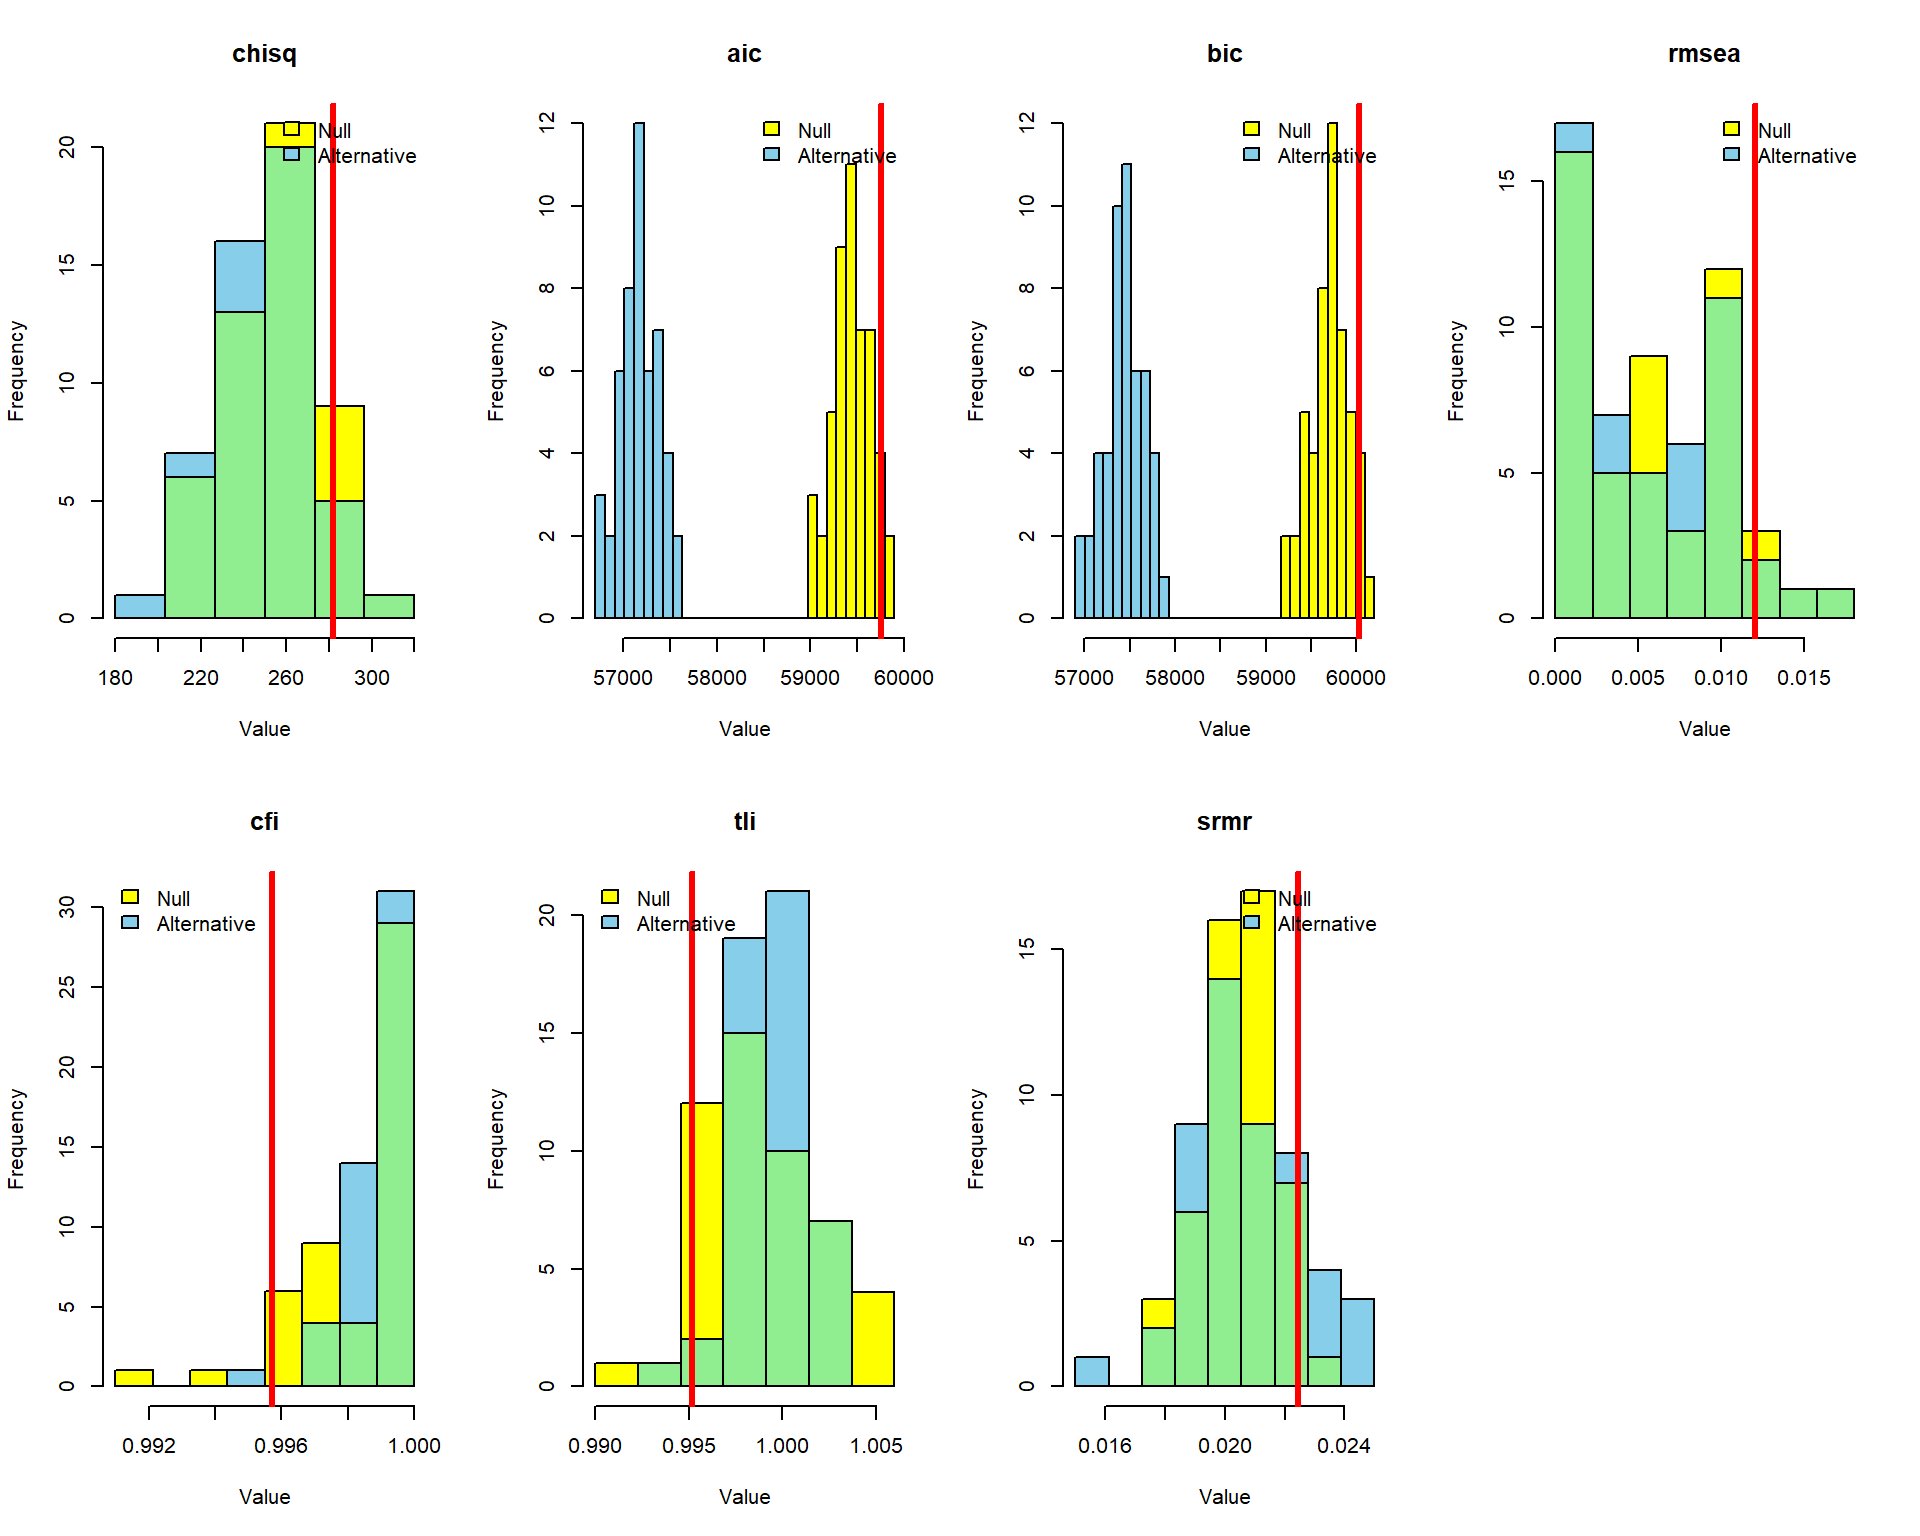

In [ ]:
#| label: fig-null-vs-alt
#| fig-cap: "Fit index distributions — Null (empirical) vs. Alternative (population)"
#| fig-width: 10
#| fig-height: 8

plotPowerFit(sim_alt, sim_null, alpha = ALPHA)

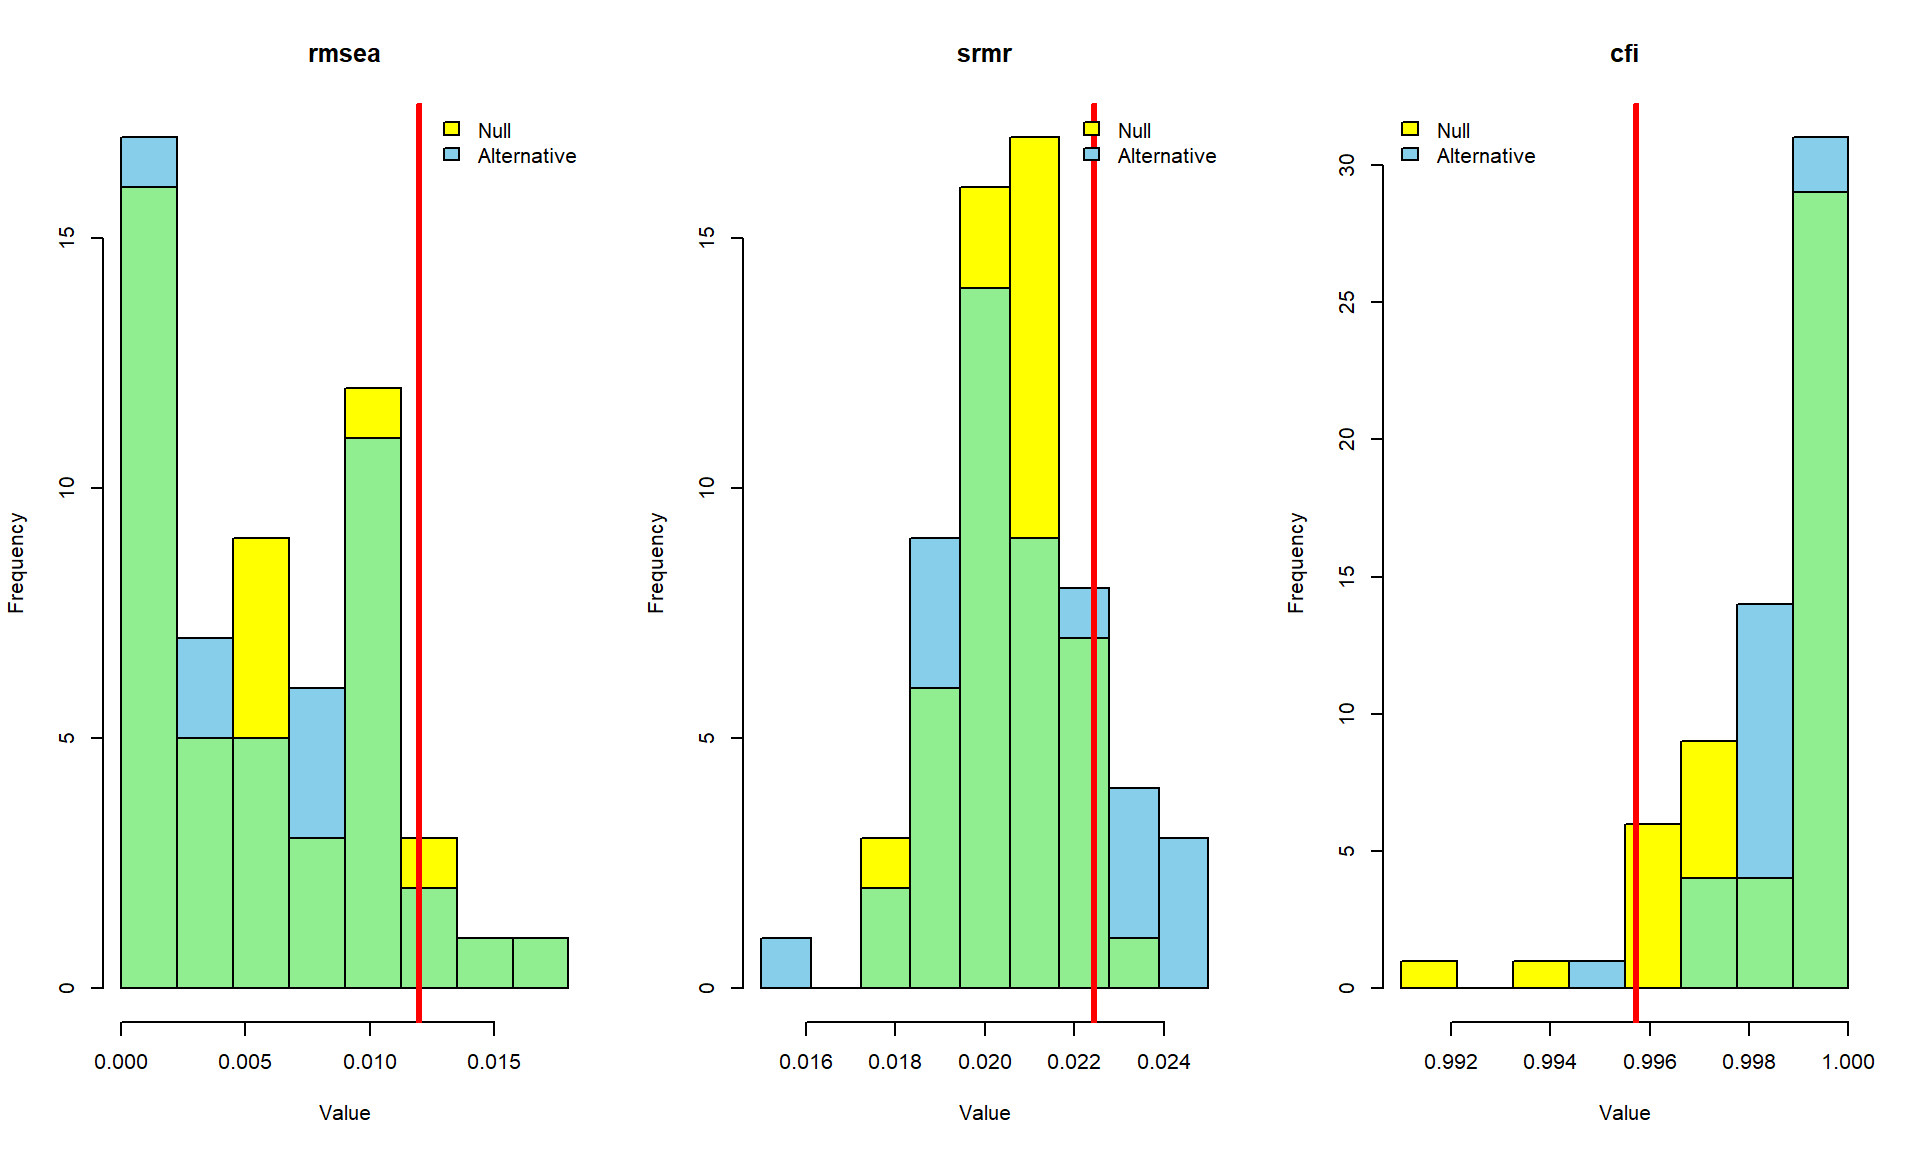

In [ ]:
#| label: fig-null-vs-alt-selected
#| fig-cap: "Selected fit indices — RMSEA, CFI, SRMR"
#| fig-width: 10
#| fig-height: 6

plotPowerFit(
  sim_alt,
  sim_null,
  alpha   = ALPHA,
  usedFit = c("rmsea", "srmr", "cfi")
)

## Summary

In [ ]:
#| label: tbl-posthoc-fit
#| tbl-cap: "Post hoc power to distinguish empirical from population model (N = 1047)"

posthoc_summary <- data.frame(
  `Fit Index` = c("RMSEA", "CFI", "TLI", "SRMR"),
  `Null Cutoff (α = .05)` = c(
    "From cutoff_null above",
    "From cutoff_null above",
    "From cutoff_null above",
    "From cutoff_null above"
  ),
  `Power` = c(
    "From getPowerFit above",
    "From getPowerFit above",
    "From getPowerFit above",
    "From getPowerFit above"
  ),
  check.names = FALSE
)

kable(posthoc_summary, align = "lcc")

  Fit Index    Null Cutoff (α = .05)            Power
  ----------- ------------------------ ------------------------
  RMSEA        From cutoff_null above   From getPowerFit above
  CFI          From cutoff_null above   From getPowerFit above
  TLI          From cutoff_null above   From getPowerFit above
  SRMR         From cutoff_null above   From getPowerFit above
